In [1]:
from utils.binaries import *
from utils.plotting import *

set_plt_style('double tex')

10:41:01 (   +1.0s) [INFO   ] -- import logging
10:41:01 (  +166ms) [INFO   ] -- import numpy as np
10:41:01 (    +6ms) [INFO   ] -- import uncertainties
10:41:01 (  +344ms) [INFO   ] -- import pandas as pd
10:41:01 (    +0ms) [WARNING] -- pandas support to be dropped at some point!
10:41:02 (    +2ms) [INFO   ] -- import binaries.tools as tools
10:41:02 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
10:41:02 (    +0ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
10:41:02 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
10:41:02 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
10:41:02 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
10:41:02 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
10:41:02 (  +349ms) [INFO   ] -- import matplotlib.pyplot as plt
10:41:02 (  +553ms) [INFO   ] -- import seabor

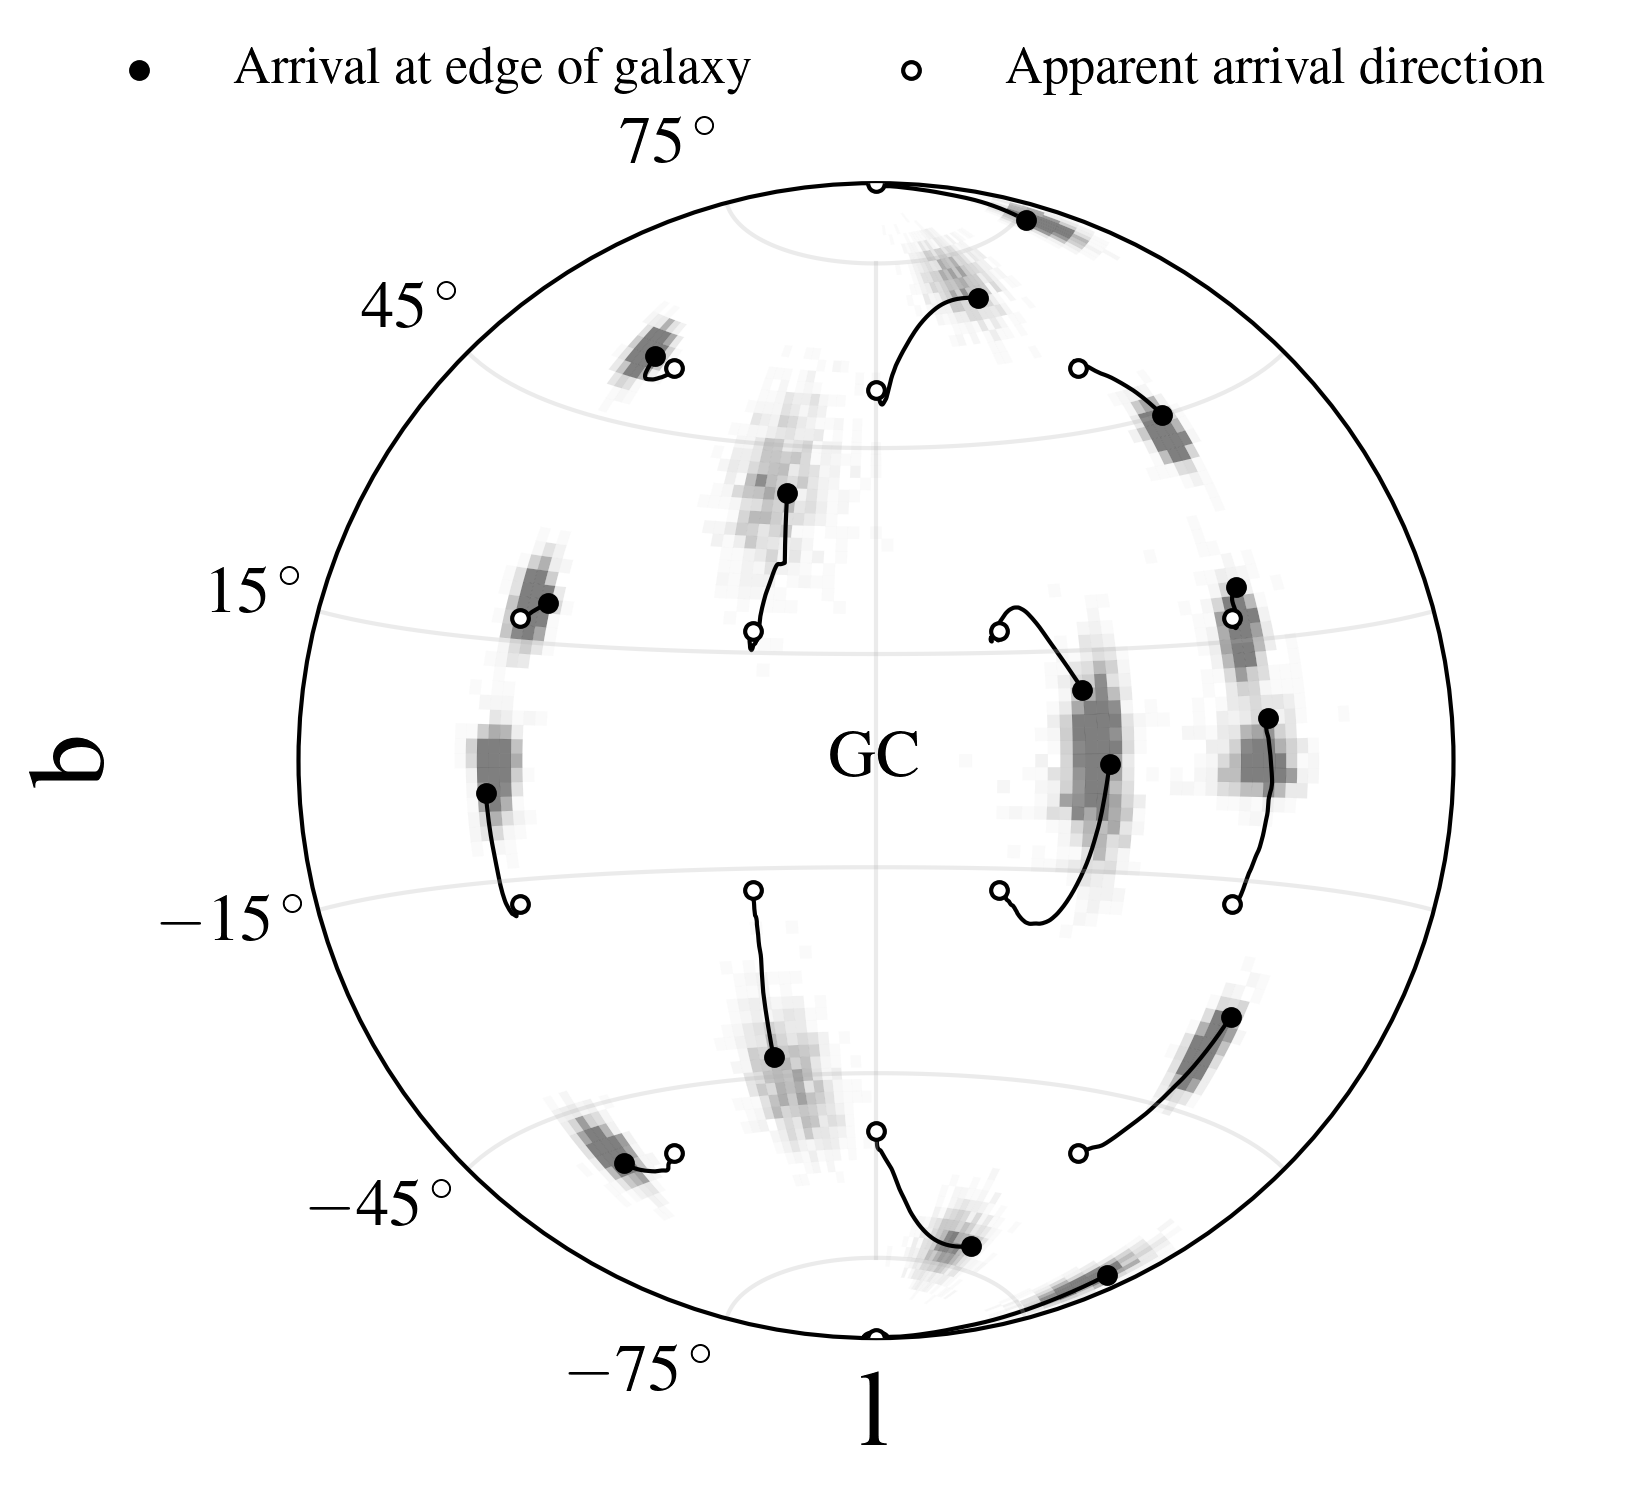

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='hammer')
ax.set_aspect("equal")

N_b = 6
N_l = {
    90: 3,
    70: 5,
    54: 5,
    50: 6,
    30: 7,
    18: 6,
    10: 8,
}

extract = lambda x: (x[0] * np.pi/180, x[-1] * np.pi/180)
source_directions = tools.pickle_load("home/quizznor/distortion_maps/distributions.pkl")

bin_number = 100
lon_edges = np.linspace(-np.pi, np.pi, bin_number + 1, endpoint=True)
lat_edges = np.linspace(-np.pi/2., np.pi/2., bin_number + 1, endpoint=True)

dist_l, dist_b = [], []

for b_in in np.linspace(-90, 90, N_b, endpoint=True):
    for l_in in np.linspace(-180, 180, N_l[np.abs(b_in)], endpoint=True)[1:-1]:

        l, b = np.loadtxt(f"home/quizznor/distortion_maps/{l_in}_{b_in}.csv", unpack=True)
        l, b = l * np.pi/180, b * np.pi/180

        if b_in == 18 and l_in == -36:
            l[-1] = -30 * np.pi/180
            b[-1] = 38 * np.pi/180

        ax.plot(l, b, lw=0.5, c='k', zorder=1, marker='none', ls='-')
        ax.scatter(l[0], b[0], fc='w', ec='k', zorder=10, lw=0.5)
        ax.scatter(l[-1], b[-1], c='k', zorder=10, lw=0.5)
        data = np.array(source_directions[f"{l_in}_{b_in}"]).T * np.pi/180
        dist_l += list(data[0])
        dist_b += list(data[1])


hist, lon_edges, lat_edges = np.histogram2d(dist_l, dist_b, 
                                            bins=[lon_edges, lat_edges], 
                                            density=True)

ax.pcolor(lon_edges[:-1], lat_edges[:-1],
          hist.T,  # transpose from (row, column) to (x, y)
          cmap=plt.cm.binary, shading='auto', vmin=0, vmax=1,
          norm='symlog', zorder=0, alpha=0.5, lw=0.01, edgecolor='face')

ax.set_ylabel("b")
ax.set_xlabel("l")
ax.scatter([], [], fc='k', ec='k', label='Arrival at edge of galaxy', lw=0.5)
ax.scatter([], [], fc='w', ec='k', label='Apparent arrival direction', lw=0.5)

ax.text(0, 0, "GC", ha='center', va='center', fontsize=8, color='k')
_ = y_ticklabels = np.array([fr"${d}\,^\circ$" for d in range(-75, 76, 30)])
ax.set_yticks(ax.get_yticks()[::2], y_ticklabels, fontsize=8)
ax.set_xticks([0], [""], fontsize=8)
ax.grid(True, alpha=0.25)
fig.legend(loc="outside upper center", ncol=2, fontsize=6.3)

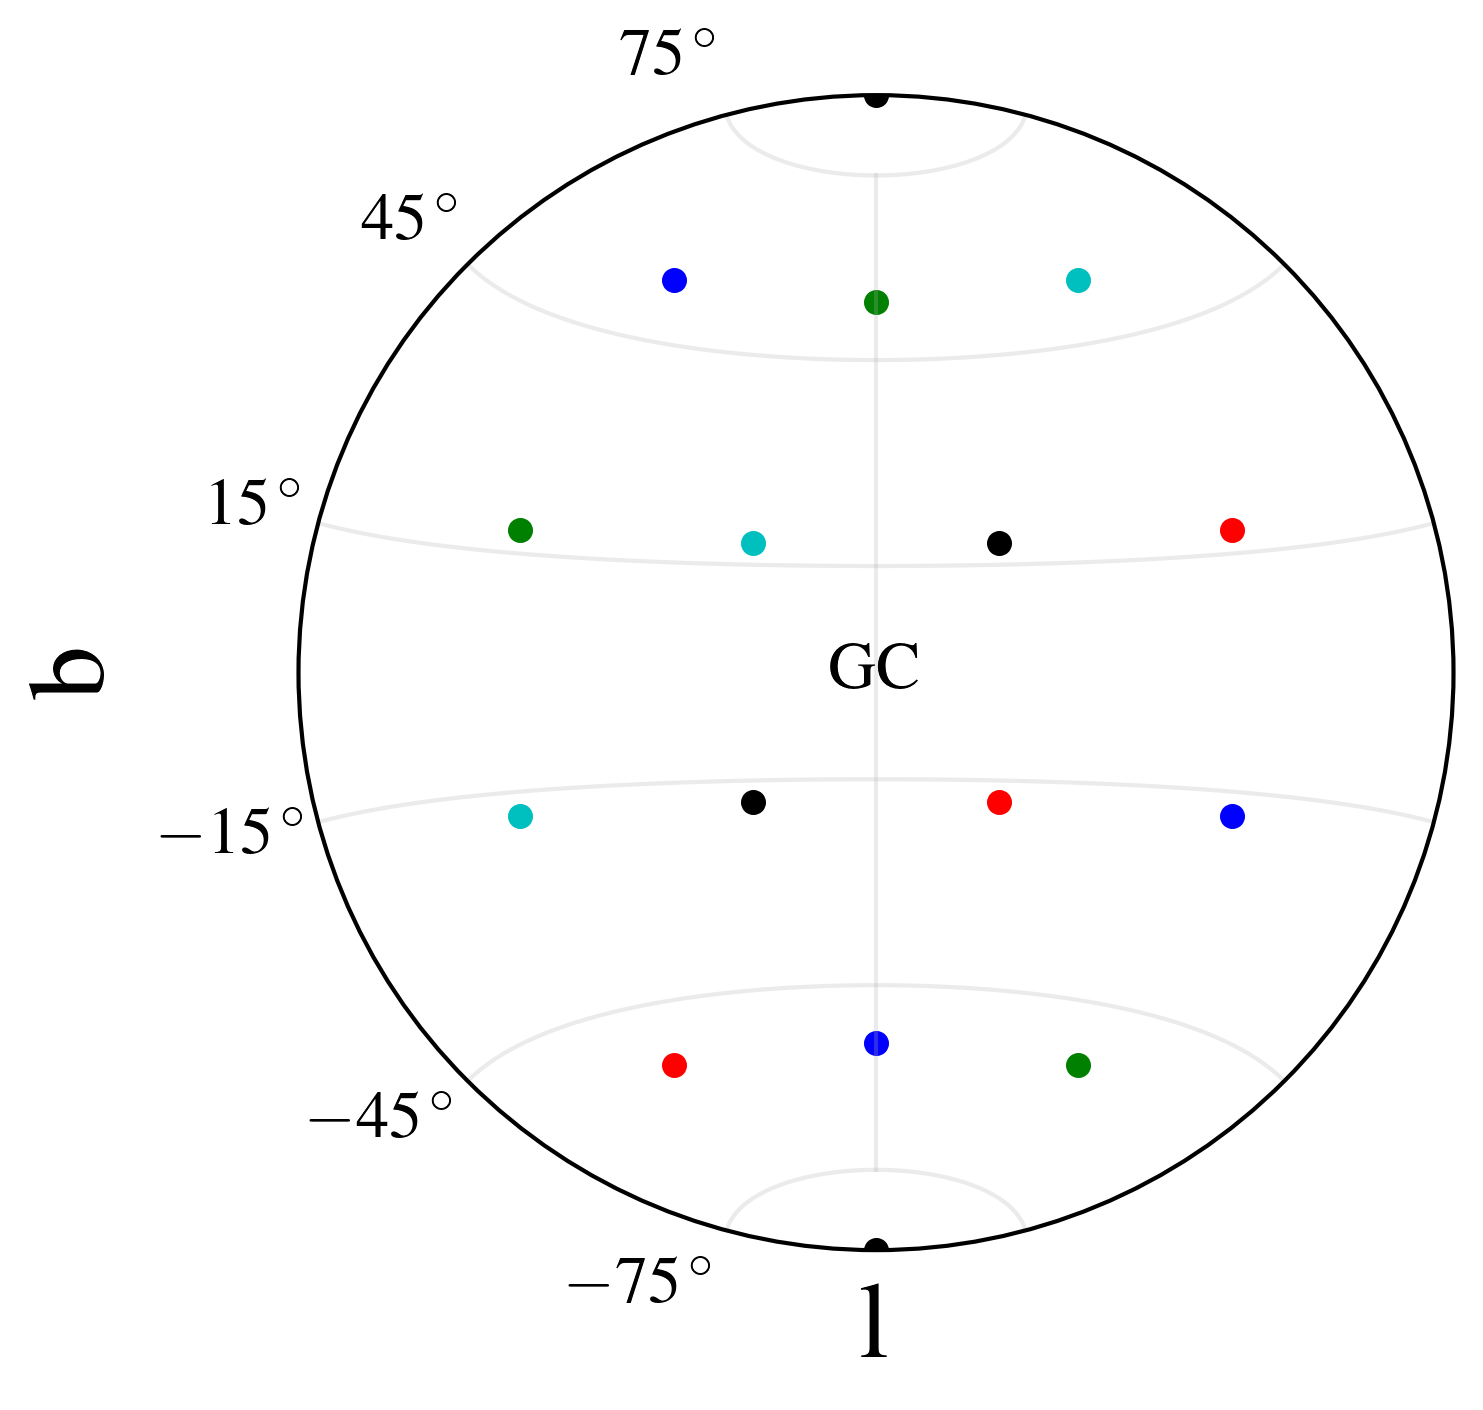

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='hammer')
ax.set_aspect("equal")

N_b = 6
N_l = {
    90: 3,
    70: 5,
    54: 5,
    50: 6,
    30: 7,
    18: 6,
    10: 8,
}

for b_in in np.linspace(-90, 90, N_b, endpoint=True):
    for l_in in np.linspace(-180, 180, N_l[np.abs(b_in)], endpoint=True)[1:-1]:

        ax.scatter(l_in * np.pi/180, b_in * np.pi/180)

ax.set_ylabel("b")
ax.set_xlabel("l")

ax.text(0, 0, "GC", ha='center', va='center', fontsize=8, color='k')
_ = y_ticklabels = np.array([fr"${d}\,^\circ$" for d in range(-75, 76, 30)])
ax.set_yticks(ax.get_yticks()[::2], y_ticklabels, fontsize=8)
ax.set_xticks([0], [""], fontsize=8)
ax.grid(True, alpha=0.25)